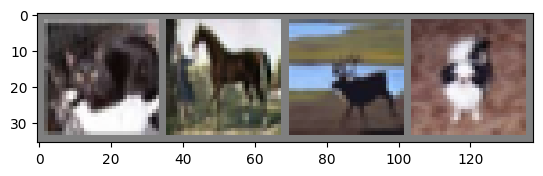

cat   horse deer  dog  
[1,  2000] loss: 2.219
[1,  4000] loss: 1.949
[1,  6000] loss: 1.704
[1,  8000] loss: 1.603
[1, 10000] loss: 1.529
[1, 12000] loss: 1.477
[2,  2000] loss: 1.398
[2,  4000] loss: 1.377
[2,  6000] loss: 1.343
[2,  8000] loss: 1.354
[2, 10000] loss: 1.319
[2, 12000] loss: 1.287
Finished Training


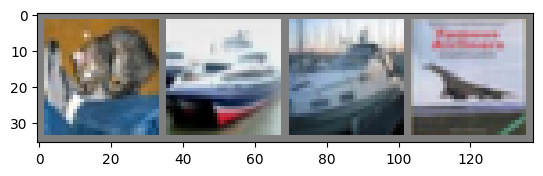

GroundTruth:  cat   ship  ship  plane
Predicted:  cat   ship  car   ship 
Accuracy of the network on the 10000 test images: 55 %
Accuracy for class: plane is 54.4 %
Accuracy for class: car   is 71.1 %
Accuracy for class: bird  is 29.7 %
Accuracy for class: cat   is 46.8 %
Accuracy for class: deer  is 41.5 %
Accuracy for class: dog   is 43.8 %
Accuracy for class: frog  is 76.6 %
Accuracy for class: horse is 59.8 %
Accuracy for class: ship  is 68.8 %
Accuracy for class: truck is 59.7 %


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
%matplotlib inline

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='/home/jupyter/work/data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='/home/jupyter/work/data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        self.conv1 = nn.Conv2d(3, 6, 5)
        # https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # Flattens the output of a multi-dimensional volume (e.g., a CONV or POOL layer) such that we can apply fully connected layers to it
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
device = torch.device('cpu')
net.to(device)

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

# Предскажем метку класса, которую выдаст нейронная сеть, и сверим её с истинным значением.
# Если предсказание верно, мы добавляем образец в список верных предсказаний.
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

# Загрузим обратно нашу сохраненную модель
# (примечание: сохранение и повторная загрузка модели здесь не были обязательными, мы сделали это только для того, чтобы проиллюстрировать, как это сделать)
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

# посмотрим, что думает нейронная сеть об этих примерах
outputs = net(images)

# Выходные данные представляют собой вероятность для 10 классов.
# Чем выше вероятность класса, тем больше сеть склонна считать, что изображение принадлежит этому классу.
# Получим индекс с максимальной энергией:

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

# посмотрим, как сеть работает со всем набором данных
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

# тоже самое, но для отдельных классов
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')
    
    